In [1]:
import polars as pl
import polars.selectors as cs

import altair as alt
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 📊 Advanced Data Science & Statistical Analysis: YouTube Top 100
This notebook performs a deep exploratory and predictive analysis on the YouTube Top 100 Songs 2025 dataset. We utilize **Polars** for lightning-fast feature engineering, **Statsmodels** for OLS linear regression and statistical inference, and **Scikit-Learn** for machine learning-based feature importance.

## Phase 1: Advanced Data Wrangling & Feature Engineering
We load the raw data and engineer several descriptive features:
- `artist`: Extracted from the video title.
- `title_length`: Character length of the video title.
- `clickbait_ratio`: The proportion of uppercase characters in the title (a proxy for clickbait intensity).
- `tag_count`: The number of unique tags attached to the video.
- `has_description_link`: Binary indicator of whether the description contains links (hyperlinks / URLs).
- `log_view_count`: Natural log of the view count to normalize the heavily skewed distribution.

In [2]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor

# Load raw parquet dataset
df_raw = pl.read_parquet("/mnt/samsung/Datasets/youtube-top-100-songs-2025.parquet")

# Feature Engineering
df = df_raw.with_columns([
    # 1. Extract artist from title (before the hyphen)
    pl.col("title").str.split("-").list.get(0).str.strip_chars().alias("artist"),
    
    # 2. Title length features
    pl.col("title").str.len_chars().alias("title_length"),
    
    # 3. Clickbait score (uppercase ratio in title)
    (pl.col("title").str.replace_all("[^A-Z]", "").str.len_chars() / 
     pl.col("title").str.replace_all("[^a-zA-Z]", "").str.len_chars()).alias("clickbait_ratio"),
    
    # 4. Number of tags
    pl.col("tags").str.split(";").list.len().alias("tag_count"),
    
    # 5. Presence of URLs in description
    pl.col("description").str.contains("(?i)https?://|www\\.").alias("has_description_link"),
    
    # 6. Log views (views span 10^3 to 10^9, log scaling is mandatory for regression modeling)
    pl.col("view_count").log().alias("log_view_count")
])

print(f"Processed Data Shape: {df.shape}")
df.select(["title", "artist", "title_length", "clickbait_ratio", "tag_count", "has_description_link", "view_count"]).head(5)

Processed Data Shape: (100, 19)


title,artist,title_length,clickbait_ratio,tag_count,has_description_link,view_count
str,str,u32,f64,u32,bool,i64
"""ROSÉ & Bruno Mars - APT. (Off…","""ROSÉ & Bruno Mars""",48,0.352941,26,true,2009014557
"""Lady Gaga, Bruno Mars - Die Wi…","""Lady Gaga, Bruno Mars""",63,0.229167,4,true,1324833300
"""Reneé Rapp - Leave Me Alone (O…","""Reneé Rapp""",50,0.210526,3,true,2536628
"""Billie Eilish - BIRDS OF A FEA…","""Billie Eilish""",57,0.444444,3,true,558329099
"""Reneé Rapp - Mad (Official Mus…","""Reneé Rapp""",39,0.206897,3,true,2113548


## Phase 2: Distribution Analysis and Outlier Detection
Let's perform a formal check on the skewness and kurtosis of view counts and identify statistical outliers (extremely viral videos) using the Interquartile Range (IQR) method.

In [3]:
# Compute Skewness and Kurtosis
skew_raw = df["view_count"].skew()
kurt_raw = df["view_count"].kurtosis()
skew_log = df["log_view_count"].skew()
kurt_log = df["log_view_count"].kurtosis()

print(f"Raw View Count: Skewness = {skew_raw:.2f}, Kurtosis = {kurt_raw:.2f}")
print(f"Log View Count: Skewness = {skew_log:.2f}, Kurtosis = {kurt_log:.2f}")

# Outlier Detection on raw view count
q1 = df["view_count"].quantile(0.25)
q3 = df["view_count"].quantile(0.75)
iqr = q3 - q1
outlier_threshold = q3 + 1.5 * iqr

outliers = df.filter(pl.col("view_count") > outlier_threshold)
print(f"\nNumber of statistical view count outliers: {len(outliers)}")
if len(outliers) > 0:
    print(outliers.select(["title", "artist", "view_count"]).sort("view_count", descending=True).head(5))

Raw View Count: Skewness = 5.81, Kurtosis = 37.80
Log View Count: Skewness = -1.59, Kurtosis = 1.73

Number of statistical view count outliers: 7
shape: (5, 3)
┌─────────────────────────────────┬───────────────────────┬────────────┐
│ title                           ┆ artist                ┆ view_count │
│ ---                             ┆ ---                   ┆ ---        │
│ str                             ┆ str                   ┆ i64        │
╞═════════════════════════════════╪═══════════════════════╪════════════╡
│ ROSÉ & Bruno Mars - APT. (Off…  ┆ ROSÉ & Bruno Mars     ┆ 2009014557 │
│ Lady Gaga, Bruno Mars - Die Wi… ┆ Lady Gaga, Bruno Mars ┆ 1324833300 │
│ Billie Eilish - BIRDS OF A FEA… ┆ Billie Eilish         ┆ 558329099  │
│ Sabrina Carpenter - Espresso    ┆ Sabrina Carpenter     ┆ 472570966  │
│ Kendrick Lamar - Not Like Us    ┆ Kendrick Lamar        ┆ 397228595  │
└─────────────────────────────────┴───────────────────────┴────────────┘


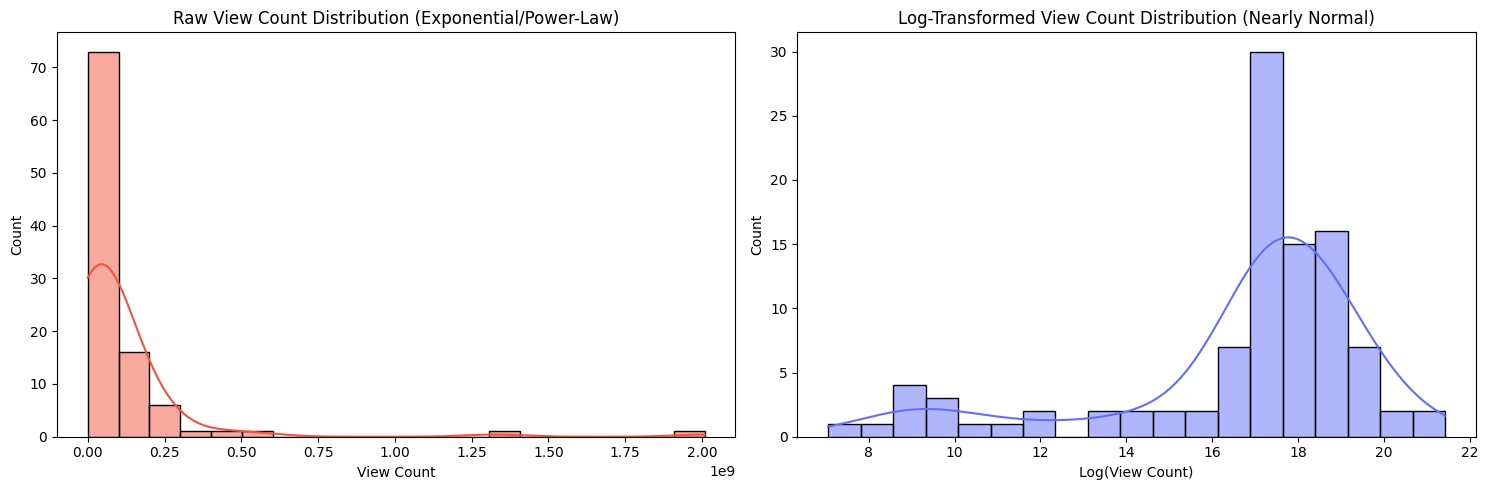

In [4]:
# Plot comparison of Raw vs. Log View Count distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df["view_count"].to_numpy(), kde=True, ax=ax1, color="#ef553b")
ax1.set_title("Raw View Count Distribution (Exponential/Power-Law)")
ax1.set_xlabel("View Count")

sns.histplot(df["log_view_count"].to_numpy(), kde=True, ax=ax2, color="#636efa")
ax2.set_title("Log-Transformed View Count Distribution (Nearly Normal)")
ax2.set_xlabel("Log(View Count)")

plt.tight_layout()
plt.show()

## Phase 3: Correlation Analysis and Ordinary Least Squares (OLS) Regression
Let's run a correlation analysis and fit an OLS regression model to evaluate the impact of various video characteristics on the song's popularity (`log_view_count`).

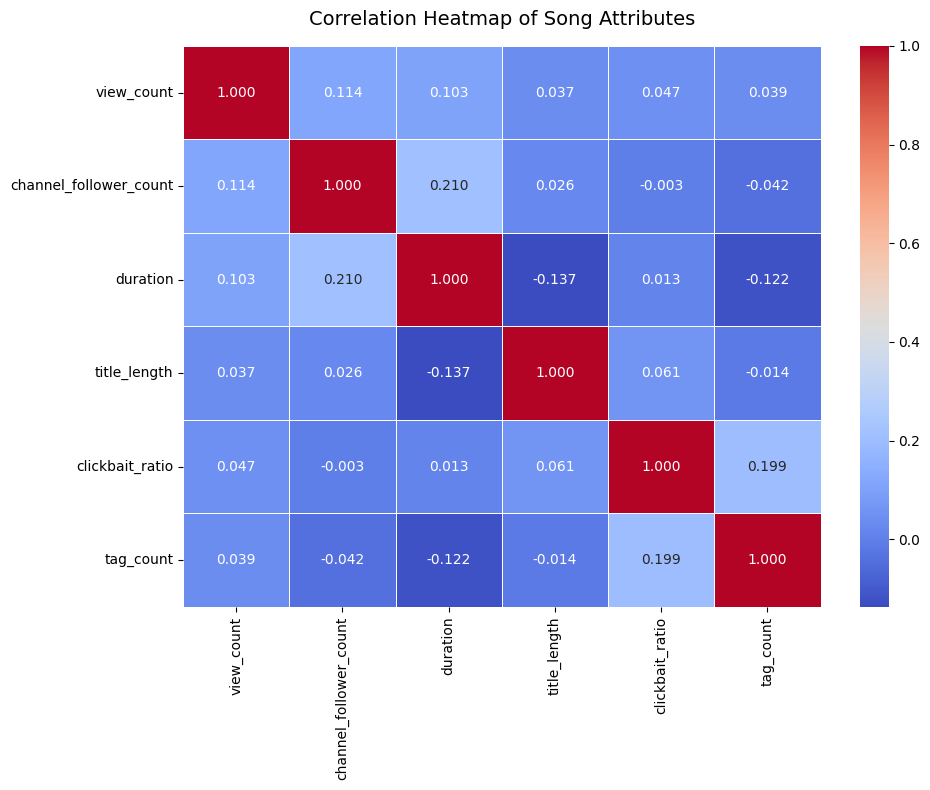

In [5]:
# Select numeric features for correlation
corr_features = ["view_count", "channel_follower_count", "duration", "title_length", "clickbait_ratio", "tag_count"]
corr_matrix = df.select(corr_features).corr()

# Heatmap Visualization
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix.to_numpy(),
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    xticklabels=corr_features,
    yticklabels=corr_features,
    linewidths=0.5
)
plt.title("Correlation Heatmap of Song Attributes", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [6]:
# OLS Linear Regression using statsmodels
# Target variable (Y): log_view_count
# Predictor variables (X): channel_follower_count, duration, title_length, clickbait_ratio, tag_count, has_description_link

df_clean = df.filter(
    pl.col("clickbait_ratio").is_not_null() &
    pl.col("log_view_count").is_not_null()
)

Y = df_clean["log_view_count"].to_numpy()
X = df_clean.select([
    "channel_follower_count",
    "duration",
    "title_length",
    "clickbait_ratio",
    "tag_count",
    "has_description_link"
]).to_pandas()

# Add intercept column for OLS
X_with_intercept = sm.add_constant(X.astype(float))

model = sm.OLS(Y, X_with_intercept).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.223
Model:                            OLS   Adj. R-squared:                  0.172
Method:                 Least Squares   F-statistic:                     4.438
Date:                Tue, 23 Jun 2026   Prob (F-statistic):           0.000543
Time:                        18:27:48   Log-Likelihood:                -240.60
No. Observations:                 100   AIC:                             495.2
Df Residuals:                      93   BIC:                             513.4
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     10

## Phase 4: Machine Learning-based Feature Importance (Random Forest)
Linear models assume linear relationships. Let's train a non-linear machine learning model (**Random Forest Regressor**) to see which features hold the highest predictive power for view count when allowing complex interactions.

In [7]:
# Train Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X.to_numpy(), Y)

# Extract Feature Importances
importances = rf.feature_importances_
feature_names = X.columns

# Create a Polars DataFrame for plotting
df_importances = pl.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort("Importance", descending=True)

print("Feature Importances:")
print(df_importances)

# Plot Feature Importance using Plotly
fig = px.bar(
    df_importances.to_pandas(),
    x="Importance",
    y="Feature",
    orientation="h",
    title="Predictive Feature Importance (Random Forest Regressor)",
    labels={"Importance": "Relative Importance", "Feature": "Attribute"},
    color="Importance",
    color_continuous_scale="Plasma"
)
fig.update_layout(yaxis=dict(autorange="reversed"), template="plotly_dark", height=450)
fig.show()

Feature Importances:
shape: (6, 2)
┌────────────────────────┬────────────┐
│ Feature                ┆ Importance │
│ ---                    ┆ ---        │
│ str                    ┆ f64        │
╞════════════════════════╪════════════╡
│ channel_follower_count ┆ 0.829804   │
│ duration               ┆ 0.058942   │
│ clickbait_ratio        ┆ 0.044974   │
│ title_length           ┆ 0.039101   │
│ tag_count              ┆ 0.025525   │
│ has_description_link   ┆ 0.001654   │
└────────────────────────┴────────────┘


## Phase 5: Advanced Categorical Analysis & Visualization
Let's look at how view counts vary across categories and analyze if categories with higher average channel follower sizes perform better.

In [8]:
# Group by Categories and compute detailed aggregates
cat_summary = df.group_by("categories").agg([
    pl.len().alias("count"),
    pl.col("view_count").mean().alias("avg_views"),
    pl.col("view_count").median().alias("median_views"),
    pl.col("channel_follower_count").mean().alias("avg_followers")
]).sort("count", descending=True)

print("Category Analysis Summary:")
print(cat_summary)

Category Analysis Summary:
shape: (2, 5)
┌────────────────┬───────┬───────────┬──────────────┬───────────────┐
│ categories     ┆ count ┆ avg_views ┆ median_views ┆ avg_followers │
│ ---            ┆ ---   ┆ ---       ┆ ---          ┆ ---           │
│ str            ┆ u32   ┆ f64       ┆ f64          ┆ f64           │
╞════════════════╪═══════╪═══════════╪══════════════╪═══════════════╡
│ Music          ┆ 94    ┆ 1.0626e8  ┆ 3.6157e7     ┆ 1.6630e7      │
│ People & Blogs ┆ 6     ┆ 1.0035e8  ┆ 1.06524812e8 ┆ 8.1437e6      │
└────────────────┴───────┴───────────┴──────────────┴───────────────┘


/tmp/ipykernel_73726/3364363342.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


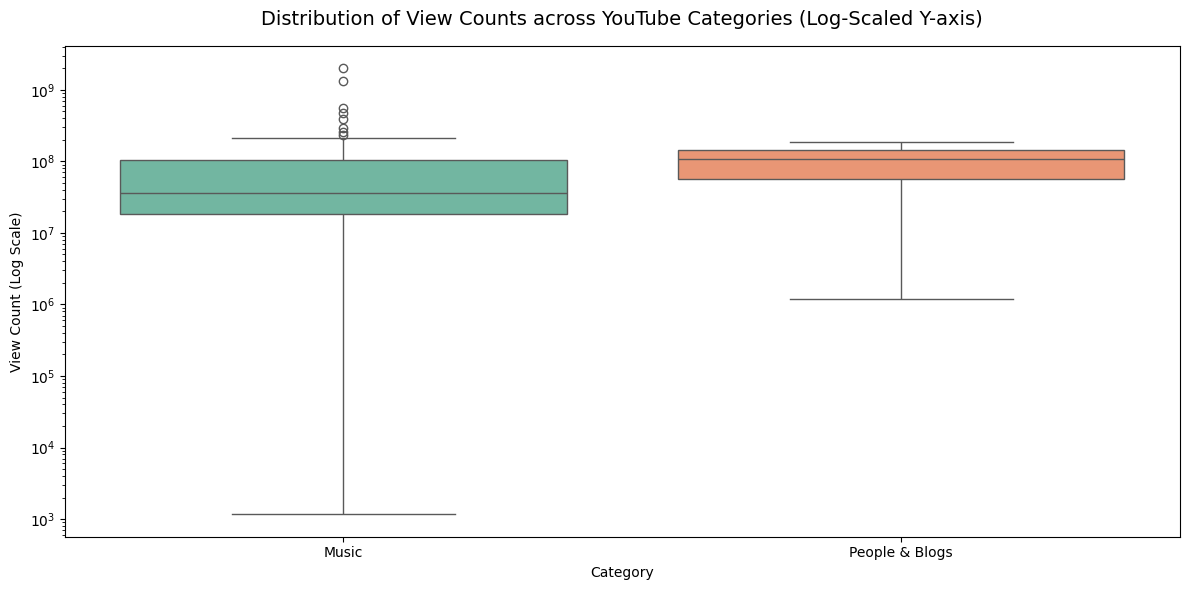

In [9]:
# Plot Violin Plot of Views by Category using Seaborn
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df.to_pandas(),
    x="categories",
    y="view_count",
    palette="Set2"
)
plt.yscale("log")
plt.title("Distribution of View Counts across YouTube Categories (Log-Scaled Y-axis)", fontsize=14, pad=15)
plt.xlabel("Category")
plt.ylabel("View Count (Log Scale)")
plt.tight_layout()
plt.show()

In [10]:
# Scatter plot with regression fit, coloring by category and scaling by duration
fig = px.scatter(
    df.to_pandas(),
    x="channel_follower_count",
    y="view_count",
    color="categories",
    size="duration",
    log_y=True,
    title="Multivariate Scatter Plot: Subscribers vs. Views (with Duration as Size)",
    labels={"channel_follower_count": "Channel Followers", "view_count": "View Count (Log Scaled)"},
    hover_data=["title", "artist"]
)
fig.update_layout(template="plotly_dark", height=600)
fig.show()